In [1]:
%pip install aaindex xgboost shap scikit-learn imbalanced-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'e:\COLLEGE\AMRITA VISHWA VIDYPEETHAM _ NEW\New folder\DD\diffusion_bbbp\ve\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from aaindex import aaindex1                         # pip install aaindex
 
from sklearn.model_selection  import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.metrics          import (accuracy_score, precision_score,
                                      recall_score, f1_score, roc_auc_score,
                                      matthews_corrcoef, average_precision_score)
from xgboost import XGBClassifier
import shap
 
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)
 
STANDARD_AA  = set("ACDEFGHIKLMNPQRSTVWY")   # 20 canonical amino acids
CSV_PATH     = r"E:\COLLEGE\AMRITA VISHWA VIDYPEETHAM _ NEW\New folder\DD\diffusion_bbbp\outputs\generated\bbbp_1000_dual.csv"                # <- change path if needed

# Re-run controls: keep False to reuse cached variables when cells are re-executed.
FORCE_RETRAIN = False
FORCE_RERUN_SVM_REPEATS = False
FORCE_RERUN_FEATURE_REDUCTION = False
FORCE_RERUN_TOP17_OVERSAMPLING = False

In [3]:
# ============================================================
# CELL 1 — Task 1 : Load CSV + AAindex Feature Encoding (86-D)
# ============================================================

def _pick_aaindex_features(target_n: int = 86) -> list[str]:
    """Pick AAindex records that have numeric values for all 20 canonical amino acids."""
    selected = []
    for fid in aaindex1.record_codes():
        try:
            rec = aaindex1[fid]
            vals = np.asarray([float(rec.values[aa]) for aa in STANDARD_AA], dtype=float)
            if np.isfinite(vals).all():
                selected.append(fid)
        except Exception:
            continue
        if len(selected) >= target_n:
            break
    if len(selected) < target_n:
        raise ValueError(
            f"Only {len(selected)} valid AAindex records found; expected at least {target_n}."
        )
    return selected


def build_aaindex_matrix(df: pd.DataFrame, feature_ids: list[str]) -> tuple[np.ndarray, list[int]]:
    """Encode each peptide as mean-pooled AAindex values across residues."""
    X_rows = []
    valid_rows = []

    for i, seq in enumerate(df["seq"]):
        residues = [aa for aa in str(seq).upper() if aa in STANDARD_AA]
        if len(residues) == 0:
            continue

        row_vals = []
        bad_row = False
        for fid in feature_ids:
            try:
                record = aaindex1[fid]
                per_residue = [float(record.values[aa]) for aa in residues]
                row_vals.append(float(np.mean(per_residue)))
            except Exception:
                bad_row = True
                break

        if bad_row:
            continue

        X_rows.append(row_vals)
        valid_rows.append(i)

    if len(X_rows) == 0:
        raise ValueError("No sequences could be AAindex-encoded. Check `seq` content in CSV.")

    return np.asarray(X_rows, dtype=float), valid_rows


# ── Run ──────────────────────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH).copy()

required_cols = {"seq", "label"}
missing_cols = sorted(required_cols - set(df_raw.columns))
if missing_cols:
    raise ValueError(f"CSV is missing required columns: {missing_cols}")

# Basic cleanup
df_raw = df_raw[df_raw["seq"].notna() & df_raw["label"].notna()].reset_index(drop=True)
df_raw["seq"] = df_raw["seq"].astype(str).str.strip().str.upper()
df_raw["label"] = pd.to_numeric(df_raw["label"], errors="coerce")
df_raw = df_raw[df_raw["label"].notna()].reset_index(drop=True)
df_raw["label"] = df_raw["label"].astype(int)

feat_names = _pick_aaindex_features(target_n=86)
X_aaindex, valid_rows = build_aaindex_matrix(df_raw, feat_names)

print(f"[CELL 1] Total rows after cleanup : {len(df_raw)}")
print(f"[CELL 1] Raw label distribution    : {df_raw['label'].value_counts().to_dict()}")
print(f"[CELL 1] Encoded rows             : {len(valid_rows)}")
print(f"[CELL 1] Feature matrix shape     : {X_aaindex.shape}")

[CELL 1] Total rows after cleanup : 1300
[CELL 1] Raw label distribution    : {1: 1000, 0: 300}
[CELL 1] Encoded rows             : 1300
[CELL 1] Feature matrix shape     : (1300, 86)


In [4]:
# ============================================================
# CELL 1b — Diagnostic: What exactly is in X_aaindex?
# ============================================================
# Run this immediately after Cell 1 to verify the feature matrix.
# ============================================================

import textwrap

# ── 1. What are the 86 AAindex IDs selected? ─────────────────────────────────
print("=" * 70)
print(f"  TOTAL AAindex properties selected : {len(feat_names)}")
print("=" * 70)
print("\n  Each ID below is one physicochemical property of amino acids.")
print("  Its full name is shown alongside.\n")

print(f"  {'#':<5} {'Record ID':<15} {'Description'}")
print(f"  {'-'*5} {'-'*15} {'-'*50}")
for i, fid in enumerate(feat_names, 1):
    try:
        desc = aaindex1[fid].description
        short_desc = textwrap.shorten(desc, width=55, placeholder="…")
    except Exception:
        short_desc = "(description unavailable)"
    print(f"  {i:<5} {fid:<15} {short_desc}")

# ── 2. How is the average computed? ──────────────────────────────────────────
print("\n" + "=" * 70)
print("  HOW THE AVERAGE IS COMPUTED (for ONE sequence)")
print("=" * 70)

example_seq   = df_raw["seq"].dropna().iloc[0]
example_label = df_raw["label"].iloc[0]

print(f"\n  Example peptide : '{example_seq}'  (label={example_label})")
print(f"  Sequence length : {len(example_seq)} residues")

# Show first 3 properties in detail
for fid in feat_names[:3]:
    record   = aaindex1[fid]
    residues = [aa for aa in example_seq.upper() if aa in STANDARD_AA]
    per_aa   = {aa: round(float(record.values[aa]), 4) for aa in residues}
    avg_val  = round(sum(per_aa.values()) / len(per_aa), 6)

    print(f"\n  Property : {fid}")
    try:
        print(f"  Desc     : {textwrap.shorten(record.description, 60, placeholder='…')}")
    except Exception:
        pass
    print(f"  Per-AA   : {per_aa}")
    print(f"  ──► MEAN across all residues = {avg_val}   ← stored in feature matrix")

print(f"\n  … same operation repeated for all {len(feat_names)} properties.")
print(f"  Result: one row of {len(feat_names)} numbers per peptide.")

# ── 3. Show the actual encoded vector for that example ───────────────────────
print("\n" + "=" * 70)
print("  ENCODED FEATURE VECTOR for the example peptide")
print("=" * 70)

row_idx  = valid_rows.index(0) if 0 in valid_rows else 0
example_vec = X_aaindex[row_idx]

print(f"\n  {'#':<5} {'Property ID':<15} {'Mean Value':>12}")
print(f"  {'-'*5} {'-'*15} {'-'*12}")
for i, (fid, val) in enumerate(zip(feat_names, example_vec), 1):
    print(f"  {i:<5} {fid:<15} {val:>12.6f}")

print(f"\n  ✔  Shape of this vector : ({len(example_vec)},)")

# ── 4. What 3 extra columns are appended in Cell 2? ──────────────────────────
print("\n" + "=" * 70)
print("  EXTRA COLUMNS in Cell 2 are optional and excluded by default")
print("=" * 70)

extra_cols = ["internal_prob", "b3pps_prob", "len"]
print(f"\n  {'Column':<15} {'Source':<20} {'Example value'}")
print(f"  {'-'*15} {'-'*20} {'-'*20}")
for col in extra_cols:
    if col in df_raw.columns:
        ex_val = df_raw[col].iloc[0]
        print(f"  {col:<15} {'directly from CSV':<20} {ex_val}")
    else:
        print(f"  {col:<15} {'NOT FOUND in CSV':<20} —")

print(f"\n  These are NOT averaged — they are taken as-is from each CSV row.")
print("  NOTE: The default training path now excludes these columns to reduce leakage/overfitting.")

# ── 5. Summary ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  FINAL FEATURE VECTOR STRUCTURE (per sample)")
print("=" * 70)
print(f"""
  Cols  1  – 86 : Mean-pooled AAindex values
                  For each of the 86 properties:
                    value = mean( property[aa] for aa in peptide_sequence )

  Total          : 86 features per sample by default
  Matrix shape   : ({len(valid_rows)}, {len(feat_names)})  ← before Cell 2 appends extras
""")

  TOTAL AAindex properties selected : 86

  Each ID below is one physicochemical property of amino acids.
  Its full name is shown alongside.

  #     Record ID       Description
  ----- --------------- --------------------------------------------------
  1     ANDN920101      alpha-CH chemical shifts (Andersen et al., 1992)
  2     ARGP820101      Hydrophobicity index (Argos et al., 1982)
  3     ARGP820102      Signal sequence helical potential (Argos et al., 1982)
  4     ARGP820103      Membrane-buried preference parameters (Argos et al.,…
  5     AURR980101      Normalized positional residue frequency at helix…
  6     AURR980102      Normalized positional residue frequency at helix…
  7     AURR980103      Normalized positional residue frequency at helix…
  8     AURR980104      Normalized positional residue frequency at helix…
  9     AURR980105      Normalized positional residue frequency at helix…
  10    AURR980106      Normalized positional residue frequency at helix…
  11  

In [5]:
aaindex_df = pd.DataFrame(X_aaindex, columns=feat_names)
aaindex_df["label"] = df_raw.iloc[valid_rows]["label"].to_numpy()
aaindex_df.to_csv("aaindex_encoded_features.csv", index=False)

In [6]:

# ============================================================
# CELL 2 — Task 2 : Data Cleaning + Combine Features (89-D)
# ============================================================

def combine_features(df: pd.DataFrame,
                     X_aa: np.ndarray,
                     valid_rows: list[int],
                     aa_feat_names: list[str],
                     extra_cols: list[str] = None
                     ) -> tuple[pd.DataFrame, pd.Series]:
    """
    Align the AAindex matrix with the original DataFrame rows,
    then concatenate numeric columns specified in `extra_cols`.

    Returns
    -------
    features_df : pd.DataFrame  (n_valid, 86 + len(extra_cols))
    labels      : pd.Series
    """
    extra_cols = extra_cols or []

    # Subset dataframe to only successfully encoded rows
    df_valid = df.iloc[valid_rows].reset_index(drop=True)

    # Build AAindex DataFrame
    aa_df = pd.DataFrame(X_aa, columns=aa_feat_names)

    # Check requested extra columns exist
    present_extras = [c for c in extra_cols if c in df_valid.columns]
    missing_extras = [c for c in extra_cols if c not in df_valid.columns]
    if missing_extras:
        print(f"  [WARN] Extra columns not found, skipping: {missing_extras}")

    extra_df = df_valid[present_extras].reset_index(drop=True)

    # Concatenate
    features_df = pd.concat([aa_df, extra_df], axis=1)
    labels      = df_valid["label"].astype(int)

    raw_dist   = df["label"].astype(int).value_counts().to_dict() if "label" in df.columns else {}
    valid_dist = labels.value_counts().to_dict()

    print(f"[CELL 2] Raw label counts     : {raw_dist}")
    print(f"[CELL 2] Valid label counts   : {valid_dist}")
    print(f"[CELL 2] Feature matrix       : {features_df.shape}  "
          f"(86 AAindex + {len(present_extras)} numeric cols)")
    if present_extras:
        print("[CELL 2] NOTE: extra numeric columns can leak signal; default training should use AAindex-only features.")

    if labels.nunique() < 2:
        raise ValueError(
            "[CELL 2] After sequence filtering/encoding, only one class remains in labels. "
            f"Raw counts={raw_dist}, valid counts={valid_dist}. "
            "Inspect `valid_rows` and failed sequences from Cell 1, then use data where both classes "
            "survive encoding."
        )

    return features_df, labels


# ── Run ──────────────────────────────────────────────────────
features_df, labels = combine_features(
    df_raw, X_aaindex, valid_rows, feat_names,
    extra_cols=[],
)

print("\n[CELL 2] Sample feature matrix (first 3 rows, last 5 cols):")
print(features_df.iloc[:3, -5:])


[CELL 2] Raw label counts     : {1: 1000, 0: 300}
[CELL 2] Valid label counts   : {1: 1000, 0: 300}
[CELL 2] Feature matrix       : (1300, 86)  (86 AAindex + 0 numeric cols)

[CELL 2] Sample feature matrix (first 3 rows, last 5 cols):
   CHOP780204  CHOP780205  CHOP780206  CHOP780207  CHOP780208
0    0.944167    0.960000    1.041667    0.966667    0.995000
1    0.937500    1.087500    0.810625    0.824375    1.484375
2    1.015556    0.798889    0.860000    0.906667    1.062222


In [7]:
# ============================================================
# CELL 3 — Task 3 : Dataset Preparation (split + scale)
# ============================================================

def prepare_dataset(features_df: pd.DataFrame,
                    labels: pd.Series,
                    test_size: float = 0.20,
                    seed: int | None = None
                    ) -> tuple:
    """
    Split into train/test and apply StandardScaler.

    seed=None gives randomized split each run.

    Returns
    -------
    X_train, X_test : np.ndarray  (scaled)
    y_train, y_test : np.ndarray
    scaler          : fitted StandardScaler
    feature_cols    : list[str]  column names (for SHAP)
    """
    feature_cols = list(features_df.columns)
    X = features_df.values
    y = labels.values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size   = test_size,
        stratify    = y,
        shuffle     = True,
        random_state= seed,
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    seed_txt = "None (randomized)" if seed is None else str(seed)
    print(f"[CELL 3] Train : {X_train.shape}  |  Test : {X_test.shape}")
    print(f"[CELL 3] Split random_state : {seed_txt}")
    print(f"[CELL 3] Train label dist : {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"[CELL 3] Test  label dist : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

    return X_train, X_test, y_train, y_test, scaler, feature_cols


# ── Run ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test, scaler, feature_cols = prepare_dataset(
    features_df, labels, seed=None
)


[CELL 3] Train : (1040, 86)  |  Test : (260, 86)
[CELL 3] Split random_state : None (randomized)
[CELL 3] Train label dist : {np.int64(0): np.int64(240), np.int64(1): np.int64(800)}
[CELL 3] Test  label dist : {np.int64(0): np.int64(60), np.int64(1): np.int64(200)}


In [8]:


# ============================================================
# CELL 4 — Task 4 & 5 : Model Training + Hyperparameter Tuning
# ============================================================

def get_model_search_spaces() -> list[dict]:
    """
    Define model + search-space configs for GridSearchCV.
    Each dict has: name, estimator, param_grid.
    """
    return [
        {
            "name"      : "LogisticRegression",
            "estimator" : LogisticRegression(
                              max_iter=1000, solver="lbfgs",
                              random_state=RANDOM_SEED),
            "param_grid": {"C": [0.01, 0.1, 1, 10]},
        },
        {
            "name"      : "RandomForest",
            "estimator" : RandomForestClassifier(
                              random_state=RANDOM_SEED, n_jobs=-1),
            "param_grid": {
                "n_estimators"      : [200, 400],
                "max_depth"         : [5, 10],
                "min_samples_split" : [10, 20],
                "min_samples_leaf"  : [2, 4],
                "max_features"      : ["sqrt", "log2"],
                "class_weight"      : [None, "balanced_subsample"],
            },
        },
        {
            "name"      : "XGBoost",
            "estimator" : XGBClassifier(
                              eval_metric="logloss", verbosity=0,
                              random_state=RANDOM_SEED, n_jobs=-1),
            "param_grid": {
                "learning_rate"    : [0.05, 0.1],
                "n_estimators"     : [100, 200],
                "max_depth"        : [3, 5],
                "subsample"        : [0.9, 1.0],
                "colsample_bytree" : [0.9, 1.0],
            },
        },
        {
            "name"      : "SVM",
            "estimator" : SVC(probability=True, random_state=RANDOM_SEED),
            "param_grid": {
                "C"      : [0.1, 1, 10, 100],
                "kernel" : ["linear", "rbf"],
                "gamma"  : ["scale", "auto"],
            },
        },
        {
            "name"      : "KNN",
            "estimator" : KNeighborsClassifier(n_jobs=-1),
            "param_grid": {
                "n_neighbors": [5, 9, 15],
                "weights"    : ["uniform", "distance"],
                "metric"     : ["euclidean", "manhattan"],
            },
        },
    ]


def train_models(X_train: np.ndarray,
                 y_train: np.ndarray,
                 seed: int = RANDOM_SEED
                 ) -> tuple[dict, dict]:
    """
    Run GridSearchCV (stratified CV, roc_auc) for every model config.

    Returns
    -------
    trained  : {name: best_estimator}
    params   : {name: best_params_dict}
    """
    classes, counts = np.unique(y_train, return_counts=True)
    class_dist = {int(c): int(n) for c, n in zip(classes, counts)}

    if len(classes) < 2:
        raise ValueError(
            "[CELL 4] Training labels contain only one class. "
            f"Found distribution: {class_dist}. "
            "Use a CSV with both label=0 and label=1 (for example bbbp_1000_dual_clf.csv), "
            "then rerun from Cell 1 onward."
        )

    min_class_count = int(counts.min())
    if min_class_count < 2:
        raise ValueError(
            "[CELL 4] Not enough minority-class samples for cross-validation. "
            f"Found distribution: {class_dist}. Need at least 2 samples in each class."
        )

    n_splits = min(5, min_class_count)
    cv       = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    configs  = get_model_search_spaces()
    trained  = {}
    params   = {}

    print(f"[CELL 4] y_train class distribution: {class_dist}")
    print(f"[CELL 4] Using StratifiedKFold with n_splits={n_splits}")

    for cfg in configs:
        name = cfg["name"]
        print(f"\n  [{name}] GridSearchCV ...", end=" ")

        search = GridSearchCV(
            estimator  = cfg["estimator"],
            param_grid = cfg["param_grid"],
            cv         = cv,
            scoring    = "roc_auc",
            refit      = True,
            n_jobs     = -1,
            verbose    = 0,
        )
        search.fit(X_train, y_train)

        trained[name] = search.best_estimator_
        params[name]  = search.best_params_

        print(f"CV-AUC={search.best_score_:.4f}  |  {search.best_params_}")

    return trained, params


# ── Run ──────────────────────────────────────────────────────
if (not FORCE_RETRAIN) and ("trained_models" in globals()) and ("best_params" in globals()):
    print("[CELL 4] Reusing cached `trained_models` and `best_params` (set FORCE_RETRAIN=True to retrain).")
else:
    print("[CELL 4] Training all models with GridSearchCV + StratifiedKFold ...")
    trained_models, best_params = train_models(X_train, y_train)
    print("\n[CELL 4] All models trained.")

[CELL 4] Training all models with GridSearchCV + StratifiedKFold ...
[CELL 4] y_train class distribution: {0: 240, 1: 800}
[CELL 4] Using StratifiedKFold with n_splits=5

  [LogisticRegression] GridSearchCV ... CV-AUC=0.8051  |  {'C': 1}

  [RandomForest] GridSearchCV ... CV-AUC=0.7946  |  {'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}

  [XGBoost] GridSearchCV ... CV-AUC=0.8048  |  {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9}

  [SVM] GridSearchCV ... CV-AUC=0.8016  |  {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

  [KNN] GridSearchCV ... CV-AUC=0.7371  |  {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}

[CELL 4] All models trained.


In [9]:
# ============================================================
# CELL 5 — Task 6 : Evaluation Metrics
# ============================================================

from pathlib import Path
from datetime import datetime

def evaluate_models(trained: dict,
                    X_test:  np.ndarray,
                    y_test:  np.ndarray) -> pd.DataFrame:
    """
    Compute Accuracy / Precision / Recall / F1 / MCC / ROC-AUC / AUC-PR for every model.
    Returns a sorted comparison DataFrame.
    """
    rows = []

    for name, model in trained.items():
        y_pred  = model.predict(X_test)
        y_score = (
            model.predict_proba(X_test)[:, 1]
            if hasattr(model, "predict_proba")
            else model.decision_function(X_test)
        )

        rows.append({
            "Model"    : name,
            "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
            "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
            "Recall"   : round(recall_score(y_test, y_pred, zero_division=0), 4),
            "F1"       : round(f1_score(y_test, y_pred, zero_division=0), 4),
            "MCC"      : round(matthews_corrcoef(y_test, y_pred), 4),
            "ROC-AUC"  : round(roc_auc_score(y_test, y_score), 4),
            "AUC-PR"   : round(average_precision_score(y_test, y_score), 4),
        })

    results_df = (
        pd.DataFrame(rows)
          .sort_values(["ROC-AUC", "AUC-PR"], ascending=False)
          .reset_index(drop=True)
    )
    return results_df


def safe_save_csv(df: pd.DataFrame, filename: str) -> str:
    """Save CSV; if target is locked, write a timestamped fallback file."""
    target = Path(filename)
    try:
        df.to_csv(target, index=False)
        return str(target)
    except PermissionError:
        stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        fallback = target.with_name(f"{target.stem}_{stamp}{target.suffix}")
        df.to_csv(fallback, index=False)
        return str(fallback)


# ── Run ──────────────────────────────────────────────────────
results_df = evaluate_models(trained_models, X_test, y_test)

print("[CELL 5] ── Model Comparison Table ──────────────────────────────")
print(results_df.to_string(index=False))
print("-" * 90)

# Optional: save to CSV
saved_path = safe_save_csv(results_df, "model_comparison.csv")
print(f"\n  Saved -> {saved_path}")

[CELL 5] ── Model Comparison Table ──────────────────────────────
             Model  Accuracy  Precision  Recall     F1    MCC  ROC-AUC  AUC-PR
               SVM    0.8000     0.8162   0.955 0.8802 0.3347   0.8535  0.9529
LogisticRegression    0.8077     0.8261   0.950 0.8837 0.3736   0.8528  0.9532
           XGBoost    0.8115     0.8326   0.945 0.8852 0.3945   0.8166  0.9337
      RandomForest    0.8077     0.8409   0.925 0.8810 0.3990   0.7957  0.9214
               KNN    0.8115     0.8213   0.965 0.8874 0.3787   0.7629  0.8957
------------------------------------------------------------------------------------------

  Saved -> model_comparison.csv


In [10]:

# ============================================================
# CELL 6 — Task 7 : Model Selection
# ============================================================

def select_best_model(results_df:     pd.DataFrame,
                      trained_models: dict,
                      best_params:    dict,
                      y_test:         np.ndarray) -> tuple[str, object]:
    """
    Select best model.
    - Primary  : ROC-AUC
    - Fallback : Recall  (when minority class < 30 %)
    """
    minority_ratio = min(y_test.mean(), 1 - y_test.mean())


    metric = "ROC-AUC" if minority_ratio < 0.30 else "ROC-AUC"

    print(f"[CELL 6] Minority class ratio : {minority_ratio:.2%}")
    print(f"[CELL 6] Selection metric     : {metric}")

    best_row  = results_df.loc[results_df[metric].idxmax()]
    best_name = best_row["Model"]
    best_est  = trained_models[best_name]

    print(f"\n  ✔  Best model     : {best_name}")
    print(f"     {metric:<12}: {best_row[metric]}")
    print(f"     Best params   : {best_params[best_name]}")

    return best_name, best_est


# ── Run ──────────────────────────────────────────────────────
best_name, best_model = select_best_model(
    results_df, trained_models, best_params, y_test
)

[CELL 6] Minority class ratio : 23.08%
[CELL 6] Selection metric     : ROC-AUC

  ✔  Best model     : SVM
     ROC-AUC     : 0.8535
     Best params   : {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [11]:
# ============================================================
# CELL 6b — SVM Repeated Experiment (10 randomized splits)
# ============================================================

def run_svm_repeated_experiments(features_df: pd.DataFrame,
                                 labels: pd.Series,
                                 n_runs: int = 10,
                                 base_seed: int = RANDOM_SEED,
                                 test_size: float = 0.20) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Train/tune SVM on n_runs different randomized train/test splits.
    Store each run's metrics and summarize mean/std.
    """
    X = features_df.values
    y = labels.values

    run_rows = []
    svm_grid = {
        "C"      : [0.1, 1, 10, 100],
        "kernel" : ["linear", "rbf"],
        "gamma"  : ["scale", "auto"],
    }

    for run in range(1, n_runs + 1):
        split_seed = base_seed + run

        X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
            X, y,
            test_size=test_size,
            stratify=y,
            shuffle=True,
            random_state=split_seed,
        )

        scaler_i = StandardScaler()
        X_train_i = scaler_i.fit_transform(X_train_i)
        X_test_i  = scaler_i.transform(X_test_i)

        cv_i = StratifiedKFold(n_splits=5, shuffle=True, random_state=split_seed)
        search_i = GridSearchCV(
            estimator=SVC(probability=True, random_state=split_seed),
            param_grid=svm_grid,
            cv=cv_i,
            scoring="roc_auc",
            refit=True,
            n_jobs=-1,
            verbose=0,
        )
        search_i.fit(X_train_i, y_train_i)

        best_svm_i = search_i.best_estimator_
        y_pred_i   = best_svm_i.predict(X_test_i)
        y_score_i  = best_svm_i.predict_proba(X_test_i)[:, 1]

        run_rows.append({
            "Run"       : run,
            "SplitSeed" : split_seed,
            "BestParams": str(search_i.best_params_),
            "Accuracy"  : round(accuracy_score(y_test_i, y_pred_i), 4),
            "Precision" : round(precision_score(y_test_i, y_pred_i, zero_division=0), 4),
            "Recall"    : round(recall_score(y_test_i, y_pred_i, zero_division=0), 4),
            "F1"        : round(f1_score(y_test_i, y_pred_i, zero_division=0), 4),
            "MCC"       : round(matthews_corrcoef(y_test_i, y_pred_i), 4),
            "ROC-AUC"   : round(roc_auc_score(y_test_i, y_score_i), 4),
            "AUC-PR"    : round(average_precision_score(y_test_i, y_score_i), 4),
        })
        print(f"[CELL 6b] Run {run:02d}/{n_runs} done | ROC-AUC={run_rows[-1]['ROC-AUC']:.4f}")

    svm_runs_df = pd.DataFrame(run_rows)
    metric_cols = ["Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC", "AUC-PR"]

    svm_summary_df = pd.DataFrame({
        "Metric": metric_cols,
        "Mean"  : [round(svm_runs_df[c].mean(), 4) for c in metric_cols],
        "Std"   : [round(svm_runs_df[c].std(ddof=1), 4) for c in metric_cols],
    })

    return svm_runs_df, svm_summary_df


# ── Run ──────────────────────────────────────────────────────
if (not FORCE_RERUN_SVM_REPEATS) and ("svm_runs_df" in globals()) and ("svm_summary_df" in globals()):
    print("[CELL 6b] Reusing cached SVM repeated-experiment outputs (set FORCE_RERUN_SVM_REPEATS=True to rerun).")
else:
    svm_runs_df, svm_summary_df = run_svm_repeated_experiments(
        features_df, labels, n_runs=10, base_seed=RANDOM_SEED, test_size=0.20
    )

    print("\n[CELL 6b] SVM results across 10 randomized splits:")
    print(svm_runs_df.to_string(index=False))

    print("\n[CELL 6b] SVM metric mean/std across 10 runs:")
    print(svm_summary_df.to_string(index=False))

    svm_runs_df.to_csv("svm_10_runs_results.csv", index=False)
    svm_summary_df.to_csv("svm_10_runs_summary.csv", index=False)
    print("\n  Saved -> svm_10_runs_results.csv")
    print("  Saved -> svm_10_runs_summary.csv")

[CELL 6b] Run 01/10 done | ROC-AUC=0.7562
[CELL 6b] Run 02/10 done | ROC-AUC=0.8145
[CELL 6b] Run 03/10 done | ROC-AUC=0.8103
[CELL 6b] Run 04/10 done | ROC-AUC=0.8573
[CELL 6b] Run 05/10 done | ROC-AUC=0.8312
[CELL 6b] Run 06/10 done | ROC-AUC=0.7884
[CELL 6b] Run 07/10 done | ROC-AUC=0.7918
[CELL 6b] Run 08/10 done | ROC-AUC=0.8236
[CELL 6b] Run 09/10 done | ROC-AUC=0.8372
[CELL 6b] Run 10/10 done | ROC-AUC=0.8430

[CELL 6b] SVM results across 10 randomized splits:
 Run  SplitSeed                                       BestParams  Accuracy  Precision  Recall     F1    MCC  ROC-AUC  AUC-PR
   1         43      {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}    0.7808     0.7967   0.960 0.8707 0.2320   0.7562  0.9166
   2         44  {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}    0.8000     0.8162   0.955 0.8802 0.3347   0.8145  0.9392
   3         45  {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}    0.8154     0.8455   0.930 0.8857 0.4243   0.8103  0.9355
   4         46 {'C': 100, '

In [12]:
# ============================================================
# CELL 6c — Fixed-Param SVM + AAindex Feature Reduction (20 -> 5)
# ============================================================

from sklearn.inspection import permutation_importance

def _svm_eval_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray) -> dict:
    """Return the same metric set used in CELL 5."""
    return {
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1"       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "MCC"      : round(matthews_corrcoef(y_true, y_pred), 4),
        "ROC-AUC"  : round(roc_auc_score(y_true, y_score), 4),
        "AUC-PR"   : round(average_precision_score(y_true, y_score), 4),
    }


def run_fixed_svm_feature_reduction(
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    feature_cols: list[str],
    aa_feature_names: list[str],
    fixed_params: dict,
    seed: int = RANDOM_SEED,
    top_k_start: int = 20,
    top_k_end: int = 5,
    perm_repeats: int = 20,
    perm_scoring: str = "roc_auc",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    1) Fit SVM with fixed params on all 86 AAindex features.
    2) Rank AAindex features using permutation importance.
    3) Evaluate top-k subsets for k = 20 down to 5 with the SAME fixed params.
    """
    aa_cols = [c for c in aa_feature_names if c in feature_cols]
    if len(aa_cols) < 20:
        raise ValueError(
            f"Need at least 20 AAindex features, found {len(aa_cols)} in feature_cols."
        )

    aa_idx_map = {c: i for i, c in enumerate(feature_cols)}
    aa_indices = [aa_idx_map[c] for c in aa_cols]

    X_train_aa = X_train[:, aa_indices]
    X_test_aa = X_test[:, aa_indices]

    svm_fixed = SVC(
        probability=True,
        random_state=seed,
        **fixed_params,
    )
    svm_fixed.fit(X_train_aa, y_train)

    y_pred_86 = svm_fixed.predict(X_test_aa)
    y_score_86 = svm_fixed.predict_proba(X_test_aa)[:, 1]
    base_metrics = _svm_eval_metrics(y_test, y_pred_86, y_score_86)

    print("[CELL 6c] Fixed SVM params (from 86-feature tuning):", fixed_params)
    print(f"[CELL 6c] AAindex feature count used for ranking: {len(aa_cols)}")
    print(f"[CELL 6c] Baseline (all {len(aa_cols)} AAindex features) metrics: {base_metrics}")

    perm = permutation_importance(
        svm_fixed,
        X_test_aa,
        y_test,
        scoring=perm_scoring,
        n_repeats=perm_repeats,
        random_state=seed,
        n_jobs=-1,
    )

    ranking_df = (
        pd.DataFrame({
            "Feature": aa_cols,
            "ImportanceMean": perm.importances_mean,
            "ImportanceStd": perm.importances_std,
        })
        .sort_values("ImportanceMean", ascending=False)
        .reset_index(drop=True)
    )

    top20_df = ranking_df.head(top_k_start).copy()
    top20_features = top20_df["Feature"].tolist()

    rows = []
    rows.append({
        "NumFeatures": len(aa_cols),
        "FeatureSet": "all_aaindex_86",
        **base_metrics,
    })

    for k in range(top_k_start, top_k_end - 1, -1):
        selected = top20_features[:k]
        idx = [aa_cols.index(f) for f in selected]

        model_k = SVC(
            probability=True,
            random_state=seed,
            **fixed_params,
        )
        model_k.fit(X_train_aa[:, idx], y_train)

        y_pred_k = model_k.predict(X_test_aa[:, idx])
        y_score_k = model_k.predict_proba(X_test_aa[:, idx])[:, 1]
        metrics_k = _svm_eval_metrics(y_test, y_pred_k, y_score_k)

        rows.append({
            "NumFeatures": k,
            "FeatureSet": ";".join(selected),
            **metrics_k,
        })

        print(
            f"[CELL 6c] Top-{k:02d} | ROC-AUC={metrics_k['ROC-AUC']:.4f} | "
            f"AUC-PR={metrics_k['AUC-PR']:.4f} | MCC={metrics_k['MCC']:.4f}"
        )

    reduction_results_df = (
        pd.DataFrame(rows)
        .sort_values("NumFeatures", ascending=False)
        .reset_index(drop=True)
    )

    return ranking_df, top20_df, reduction_results_df


# ── Run ──────────────────────────────────────────────────────
# Use SVM best parameters from CELL 4 (tuned on full feature space).
if (not FORCE_RERUN_FEATURE_REDUCTION) and ("svm_feature_ranking_df" in globals()) and ("svm_top20_df" in globals()) and ("svm_reduction_results_df" in globals()):
    print("[CELL 6c] Reusing cached feature-reduction outputs (set FORCE_RERUN_FEATURE_REDUCTION=True to rerun).")
else:
    if "SVM" not in best_params:
        raise ValueError(
            "SVM hyperparameters not found in `best_params`. Run CELL 4 first."
        )

    fixed_svm_params = dict(best_params["SVM"])
    aaindex_feature_names = list(feat_names)  # canonical 86 AAindex IDs selected in CELL 1

    svm_feature_ranking_df, svm_top20_df, svm_reduction_results_df = run_fixed_svm_feature_reduction(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        feature_cols=feature_cols,
        aa_feature_names=aaindex_feature_names,
        fixed_params=fixed_svm_params,
        seed=RANDOM_SEED,
        top_k_start=20,
        top_k_end=5,
        perm_repeats=20,
        perm_scoring="roc_auc",
    )

    print("\n[CELL 6c] Top-20 AAindex features by permutation importance:")
    print(svm_top20_df.to_string(index=False))

    print("\n[CELL 6c] Fixed-parameter SVM results (86 + top-20..top-5):")
    print(svm_reduction_results_df[[
        "NumFeatures", "Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC", "AUC-PR"
    ]].to_string(index=False))

    svm_feature_ranking_df.to_csv("svm_fixed_aaindex_feature_ranking.csv", index=False)
    svm_top20_df.to_csv("svm_fixed_top20_features.csv", index=False)
    svm_reduction_results_df.to_csv("svm_fixed_feature_reduction_20_to_5.csv", index=False)

    print("\n  Saved -> svm_fixed_aaindex_feature_ranking.csv")
    print("  Saved -> svm_fixed_top20_features.csv")
    print("  Saved -> svm_fixed_feature_reduction_20_to_5.csv")

[CELL 6c] Fixed SVM params (from 86-feature tuning): {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
[CELL 6c] AAindex feature count used for ranking: 86
[CELL 6c] Baseline (all 86 AAindex features) metrics: {'Accuracy': 0.8, 'Precision': 0.8162, 'Recall': 0.955, 'F1': 0.8802, 'MCC': 0.3347, 'ROC-AUC': 0.8535, 'AUC-PR': 0.9529}
[CELL 6c] Top-20 | ROC-AUC=0.8586 | AUC-PR=0.9557 | MCC=0.3478
[CELL 6c] Top-19 | ROC-AUC=0.8515 | AUC-PR=0.9519 | MCC=0.2984
[CELL 6c] Top-18 | ROC-AUC=0.8528 | AUC-PR=0.9529 | MCC=0.3168
[CELL 6c] Top-17 | ROC-AUC=0.8175 | AUC-PR=0.9377 | MCC=0.3759
[CELL 6c] Top-16 | ROC-AUC=0.8107 | AUC-PR=0.9336 | MCC=0.3558
[CELL 6c] Top-15 | ROC-AUC=0.8175 | AUC-PR=0.9368 | MCC=0.3547
[CELL 6c] Top-14 | ROC-AUC=0.8178 | AUC-PR=0.9385 | MCC=0.3541
[CELL 6c] Top-13 | ROC-AUC=0.8237 | AUC-PR=0.9413 | MCC=0.0000
[CELL 6c] Top-12 | ROC-AUC=0.8252 | AUC-PR=0.9416 | MCC=0.0000
[CELL 6c] Top-11 | ROC-AUC=0.7992 | AUC-PR=0.9303 | MCC=0.0000
[CELL 6c] Top-10 | ROC-AUC=0.8151 | AUC-P

In [13]:
# Guard defaults when running mid-notebook (without re-running the config/import cell).
FORCE_RETRAIN = globals().get("FORCE_RETRAIN", False)
FORCE_RERUN_SVM_REPEATS = globals().get("FORCE_RERUN_SVM_REPEATS", False)
FORCE_RERUN_FEATURE_REDUCTION = globals().get("FORCE_RERUN_FEATURE_REDUCTION", False)
FORCE_RERUN_TOP17_OVERSAMPLING = globals().get("FORCE_RERUN_TOP17_OVERSAMPLING", False)
print("[Guard] Rerun flags are initialized.")

[Guard] Rerun flags are initialized.


In [14]:
# ============================================================
# CELL 6d — Fixed-Param SVM on Top-17 + Resampling Comparison
# ============================================================

def run_fixed_svm_top17_resampling_comparison(
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    feature_cols: list[str],
    aa_feature_names: list[str],
    ranking_df: pd.DataFrame,
    fixed_params: dict,
    target_k: int = 17,
    positive_label: int = 1,
    methods: list[str] | None = None,
    seed: int = RANDOM_SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """
    Compare RandomOverSampler, SMOTE, and ADASYN on the same top-k features,
    with the SAME fixed SVM hyperparameters.
    """
    from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

    if target_k < 1:
        raise ValueError("target_k must be >= 1")

    if ranking_df.empty:
        raise ValueError("ranking_df is empty. Run CELL 6c first.")

    methods = methods or ["random", "smote", "adasyn"]
    methods = [m.lower() for m in methods]
    allowed = {"random", "smote", "adasyn"}
    bad = [m for m in methods if m not in allowed]
    if bad:
        raise ValueError(f"Unsupported methods: {bad}. Allowed: {sorted(allowed)}")

    aa_cols = [c for c in aa_feature_names if c in feature_cols]
    if len(aa_cols) < target_k:
        raise ValueError(f"Need at least {target_k} AAindex features, found {len(aa_cols)}.")

    feature_cols_map = {c: i for i, c in enumerate(feature_cols)}
    aa_indices = [feature_cols_map[c] for c in aa_cols]

    X_train_aa = X_train[:, aa_indices]
    X_test_aa = X_test[:, aa_indices]

    topk_features = ranking_df["Feature"].head(target_k).tolist()
    aa_pos_map = {c: i for i, c in enumerate(aa_cols)}
    topk_idx = [aa_pos_map[f] for f in topk_features]

    X_train_k = X_train_aa[:, topk_idx]
    X_test_k = X_test_aa[:, topk_idx]

    classes, counts = np.unique(y_train, return_counts=True)
    class_count_map = {int(c): int(n) for c, n in zip(classes, counts)}
    if positive_label not in class_count_map:
        raise ValueError(
            f"Positive label {positive_label} not found in y_train. "
            f"Available labels: {sorted(np.unique(y_train).tolist())}"
        )
    if len(class_count_map) != 2:
        raise ValueError(f"Expected binary labels for this step, got: {class_count_map}")

    minority_count = min(class_count_map.values())
    if minority_count < 2 and ("smote" in methods or "adasyn" in methods):
        raise ValueError(
            "SMOTE/ADASYN requires at least 2 minority samples in y_train. "
            f"Class counts: {class_count_map}"
        )

    sampler_map = {
        "random": RandomOverSampler(random_state=seed),
        "smote": SMOTE(random_state=seed, k_neighbors=min(5, minority_count - 1)),
        "adasyn": ADASYN(random_state=seed, n_neighbors=min(5, minority_count - 1)),
    }

    rows = []
    method_meta = {}

    for method in methods:
        sampler = sampler_map[method]
        X_res, y_res = sampler.fit_resample(X_train_k, y_train)

        model = SVC(
            probability=True,
            random_state=seed,
            **fixed_params,
        )
        model.fit(X_res, y_res)

        y_pred = model.predict(X_test_k)
        y_score = model.predict_proba(X_test_k)[:, 1]
        metrics = _svm_eval_metrics(y_test, y_pred, y_score)

        res_classes, res_counts = np.unique(y_res, return_counts=True)
        res_count_map = {int(c): int(n) for c, n in zip(res_classes, res_counts)}
        method_meta[method] = {
            "TrainClassCountBefore": class_count_map,
            "TrainClassCountAfter": res_count_map,
        }

        rows.append({
            "Method": method,
            "NumFeatures": target_k,
            "TrainPosBefore": int(class_count_map.get(positive_label, 0)),
            "TrainPosAfter": int(res_count_map.get(positive_label, 0)),
            "FixedParams": str(fixed_params),
            **metrics,
        })

        print(
            f"[CELL 6d] {method.upper():>6} | "
            f"Train counts {class_count_map} -> {res_count_map} | "
            f"ROC-AUC={metrics['ROC-AUC']:.4f} | AUC-PR={metrics['AUC-PR']:.4f}"
        )

    results_df = (
        pd.DataFrame(rows)
        .sort_values(["ROC-AUC", "AUC-PR", "MCC"], ascending=False)
        .reset_index(drop=True)
    )
    topk_df = pd.DataFrame({"Feature": topk_features})

    topk_df.to_csv("svm_fixed_top17_features.csv", index=False)
    results_df.to_csv("svm_fixed_top17_resampling_comparison.csv", index=False)

    print("\n[CELL 6d] Using same fixed SVM params:", fixed_params)
    print(f"[CELL 6d] Top-{target_k} features selected from CELL 6c ranking.")
    print("\n  Saved -> svm_fixed_top17_features.csv")
    print("  Saved -> svm_fixed_top17_resampling_comparison.csv")

    return topk_df, results_df, method_meta


# ── Run ──────────────────────────────────────────────────────
if "fixed_svm_params" not in globals() and "best_params" in globals() and "SVM" in best_params:
    fixed_svm_params = dict(best_params["SVM"])

if (not FORCE_RERUN_TOP17_OVERSAMPLING) and ("svm_top17_resampling_df" in globals()) and ("svm_top17_resampling_meta" in globals()):
    print(
        "[CELL 6d] Reusing cached top-17 resampling comparison outputs "
        "(set FORCE_RERUN_TOP17_OVERSAMPLING=True to rerun)."
    )
else:
    if "svm_feature_ranking_df" not in globals() or svm_feature_ranking_df.empty:
        raise ValueError("Top-feature ranking not available. Run CELL 6c first.")

    if "fixed_svm_params" not in globals():
        if "SVM" not in best_params:
            raise ValueError("SVM hyperparameters not found. Run CELL 4 (and CELL 6c) first.")
        fixed_svm_params = dict(best_params["SVM"])

    svm_top17_df, svm_top17_resampling_df, svm_top17_resampling_meta = run_fixed_svm_top17_resampling_comparison(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        feature_cols=feature_cols,
        aa_feature_names=list(feat_names),
        ranking_df=svm_feature_ranking_df,
        fixed_params=fixed_svm_params,
        target_k=17,
        positive_label=1,
        methods=["random", "smote", "adasyn"],
        seed=RANDOM_SEED,
    )

    print("\n[CELL 6d] Resampling method comparison:")
    print(
        svm_top17_resampling_df[[
            "Method", "NumFeatures", "Accuracy", "Precision", "Recall",
            "F1", "MCC", "ROC-AUC", "AUC-PR"
        ]].to_string(index=False)
    )

[CELL 6d] RANDOM | Train counts {0: 240, 1: 800} -> {0: 800, 1: 800} | ROC-AUC=0.8159 | AUC-PR=0.9390
[CELL 6d]  SMOTE | Train counts {0: 240, 1: 800} -> {0: 800, 1: 800} | ROC-AUC=0.8248 | AUC-PR=0.9428
[CELL 6d] ADASYN | Train counts {0: 240, 1: 800} -> {0: 812, 1: 800} | ROC-AUC=0.8156 | AUC-PR=0.9387

[CELL 6d] Using same fixed SVM params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
[CELL 6d] Top-17 features selected from CELL 6c ranking.

  Saved -> svm_fixed_top17_features.csv
  Saved -> svm_fixed_top17_resampling_comparison.csv

[CELL 6d] Resampling method comparison:
Method  NumFeatures  Accuracy  Precision  Recall     F1    MCC  ROC-AUC  AUC-PR
 smote           17    0.7538     0.8908   0.775 0.8289 0.4104   0.8248  0.9428
random           17    0.7462     0.8988   0.755 0.8207 0.4156   0.8159  0.9390
adasyn           17    0.7346     0.8876   0.750 0.8130 0.3828   0.8156  0.9387


In [15]:
# ============================================================
# CELL 6e — Top-17 Only: 5 Random Splits (No-SMOTE vs SMOTE)
# ============================================================

from imblearn.over_sampling import SMOTE

def run_top17_smote_vs_no_smote_5splits(
    features_df: pd.DataFrame,
    labels: pd.Series,
    ranking_df: pd.DataFrame,
    fixed_params: dict,
    n_runs: int = 5,
    base_seed: int = RANDOM_SEED,
    test_size: float = 0.20,
    target_k: int = 17,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    For each randomized split, compare Top-17 SVM performance with:
      1) No-SMOTE
      2) SMOTE on training split only
    """
    if ranking_df.empty:
        raise ValueError("`ranking_df` is empty. Run CELL 6c first.")

    top17_features = ranking_df["Feature"].head(target_k).tolist()
    if len(top17_features) < target_k:
        raise ValueError(f"Expected {target_k} ranked features, found {len(top17_features)}.")

    missing = [f for f in top17_features if f not in features_df.columns]
    if missing:
        raise ValueError(f"Top-17 features missing in features_df: {missing}")

    X_all = features_df[top17_features].to_numpy()
    y_all = labels.to_numpy()

    rows = []
    for run in range(1, n_runs + 1):
        split_seed = base_seed + run

        X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
            X_all, y_all,
            test_size=test_size,
            stratify=y_all,
            shuffle=True,
            random_state=split_seed,
        )

        scaler_i = StandardScaler()
        X_train_i = scaler_i.fit_transform(X_train_i)
        X_test_i = scaler_i.transform(X_test_i)

        # 1) No-SMOTE
        model_no = SVC(probability=True, random_state=split_seed, **fixed_params)
        model_no.fit(X_train_i, y_train_i)
        y_pred_no = model_no.predict(X_test_i)
        y_score_no = model_no.predict_proba(X_test_i)[:, 1]
        metrics_no = _svm_eval_metrics(y_test_i, y_pred_no, y_score_no)

        before_counts = dict(zip(*np.unique(y_train_i, return_counts=True)))

        rows.append({
            "Run": run,
            "SplitSeed": split_seed,
            "Method": "no_smote",
            "NumFeatures": target_k,
            "TrainClassCountsBefore": str(before_counts),
            "TrainClassCountsAfter": str(before_counts),
            **metrics_no,
        })

        # 2) SMOTE
        classes_i, counts_i = np.unique(y_train_i, return_counts=True)
        class_map_i = {int(c): int(n) for c, n in zip(classes_i, counts_i)}
        minority_count = min(class_map_i.values())
        if minority_count < 2:
            raise ValueError(
                f"Run {run}: SMOTE requires at least 2 minority samples. Found {class_map_i}"
            )

        smote = SMOTE(random_state=split_seed, k_neighbors=min(5, minority_count - 1))
        X_res_i, y_res_i = smote.fit_resample(X_train_i, y_train_i)

        model_sm = SVC(probability=True, random_state=split_seed, **fixed_params)
        model_sm.fit(X_res_i, y_res_i)
        y_pred_sm = model_sm.predict(X_test_i)
        y_score_sm = model_sm.predict_proba(X_test_i)[:, 1]
        metrics_sm = _svm_eval_metrics(y_test_i, y_pred_sm, y_score_sm)

        after_counts = dict(zip(*np.unique(y_res_i, return_counts=True)))

        rows.append({
            "Run": run,
            "SplitSeed": split_seed,
            "Method": "smote",
            "NumFeatures": target_k,
            "TrainClassCountsBefore": str(before_counts),
            "TrainClassCountsAfter": str(after_counts),
            **metrics_sm,
        })

        print(
            f"[CELL 6e] Run {run}/{n_runs} | "
            f"No-SMOTE ROC-AUC={metrics_no['ROC-AUC']:.4f} | "
            f"SMOTE ROC-AUC={metrics_sm['ROC-AUC']:.4f}"
        )

    runs_df = pd.DataFrame(rows).sort_values(["Run", "Method"]).reset_index(drop=True)

    metric_cols = ["Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC", "AUC-PR"]
    summary_rows = []
    for method in ["no_smote", "smote"]:
        sub = runs_df[runs_df["Method"] == method]
        for m in metric_cols:
            summary_rows.append({
                "Method": method,
                "Metric": m,
                "Mean": round(sub[m].mean(), 4),
                "Std": round(sub[m].std(ddof=1), 4),
            })

    summary_df = pd.DataFrame(summary_rows)
    return runs_df, summary_df


# ── Run ──────────────────────────────────────────────────────
FORCE_RERUN_TOP17_5SPLIT = globals().get("FORCE_RERUN_TOP17_5SPLIT", False)

if "fixed_svm_params" not in globals():
    if "best_params" in globals() and "SVM" in best_params:
        fixed_svm_params = dict(best_params["SVM"])
    else:
        raise ValueError("SVM hyperparameters not found. Run CELL 4 and CELL 6c first.")

if (
    (not FORCE_RERUN_TOP17_5SPLIT)
    and ("svm_top17_smote_5split_runs_df" in globals())
    and ("svm_top17_smote_5split_summary_df" in globals())
):
    print(
        "[CELL 6e] Reusing cached 5-split Top-17 No-SMOTE vs SMOTE outputs "
        "(set FORCE_RERUN_TOP17_5SPLIT=True to rerun)."
    )
else:
    if "svm_feature_ranking_df" not in globals() or svm_feature_ranking_df.empty:
        raise ValueError("Top-feature ranking not available. Run CELL 6c first.")

    svm_top17_smote_5split_runs_df, svm_top17_smote_5split_summary_df = run_top17_smote_vs_no_smote_5splits(
        features_df=features_df,
        labels=labels,
        ranking_df=svm_feature_ranking_df,
        fixed_params=fixed_svm_params,
        n_runs=5,
        base_seed=RANDOM_SEED,
        test_size=0.20,
        target_k=17,
    )

    print("\n[CELL 6e] Per-run results (Top-17 only):")
    print(
        svm_top17_smote_5split_runs_df[[
            "Run", "SplitSeed", "Method", "NumFeatures",
            "Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC", "AUC-PR"
        ]].to_string(index=False)
    )

    print("\n[CELL 6e] Mean ± Std across 5 random splits:")
    print(svm_top17_smote_5split_summary_df.to_string(index=False))

    svm_top17_smote_5split_runs_df.to_csv("svm_top17_no_smote_vs_smote_5splits_runs.csv", index=False)
    svm_top17_smote_5split_summary_df.to_csv("svm_top17_no_smote_vs_smote_5splits_summary.csv", index=False)
    print("\n  Saved -> svm_top17_no_smote_vs_smote_5splits_runs.csv")
    print("  Saved -> svm_top17_no_smote_vs_smote_5splits_summary.csv")

[CELL 6e] Run 1/5 | No-SMOTE ROC-AUC=0.7722 | SMOTE ROC-AUC=0.7669
[CELL 6e] Run 2/5 | No-SMOTE ROC-AUC=0.7762 | SMOTE ROC-AUC=0.7736
[CELL 6e] Run 3/5 | No-SMOTE ROC-AUC=0.7810 | SMOTE ROC-AUC=0.7913
[CELL 6e] Run 4/5 | No-SMOTE ROC-AUC=0.8253 | SMOTE ROC-AUC=0.8098
[CELL 6e] Run 5/5 | No-SMOTE ROC-AUC=0.8051 | SMOTE ROC-AUC=0.8300

[CELL 6e] Per-run results (Top-17 only):
 Run  SplitSeed   Method  NumFeatures  Accuracy  Precision  Recall     F1    MCC  ROC-AUC  AUC-PR
   1         43 no_smote           17    0.7731     0.7925   0.955 0.8662 0.1970   0.7722  0.9215
   1         43    smote           17    0.7269     0.8772   0.750 0.8086 0.3552   0.7669  0.9194
   2         44 no_smote           17    0.7731     0.7878   0.965 0.8674 0.1777   0.7762  0.9231
   2         44    smote           17    0.6923     0.8750   0.700 0.7778 0.3175   0.7736  0.9230
   3         45 no_smote           17    0.8000     0.8217   0.945 0.8791 0.3451   0.7810  0.9206
   3         45    smote           


[CELL 7] SHAP analysis for 'SVM' …
  Using KernelExplainer (background = 100 train samples) …
  Generating SHAP values beeswarm plot with all 86 features …


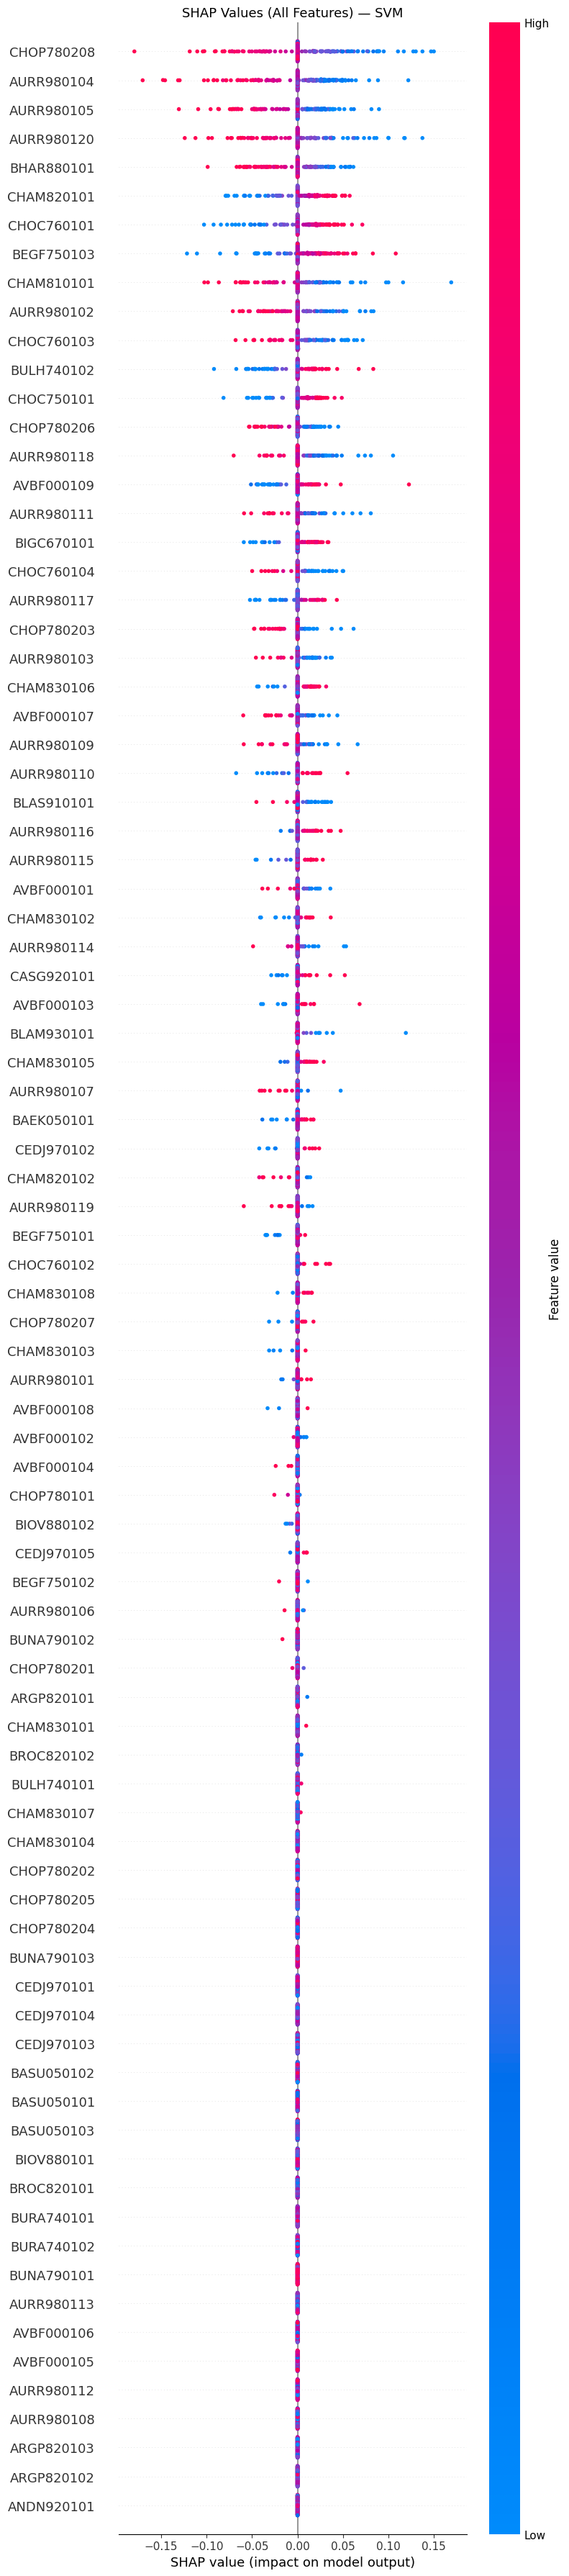

  Saved → shap_values_plot_all_86.png
  Generating SHAP summary bar plot with all 86 features …


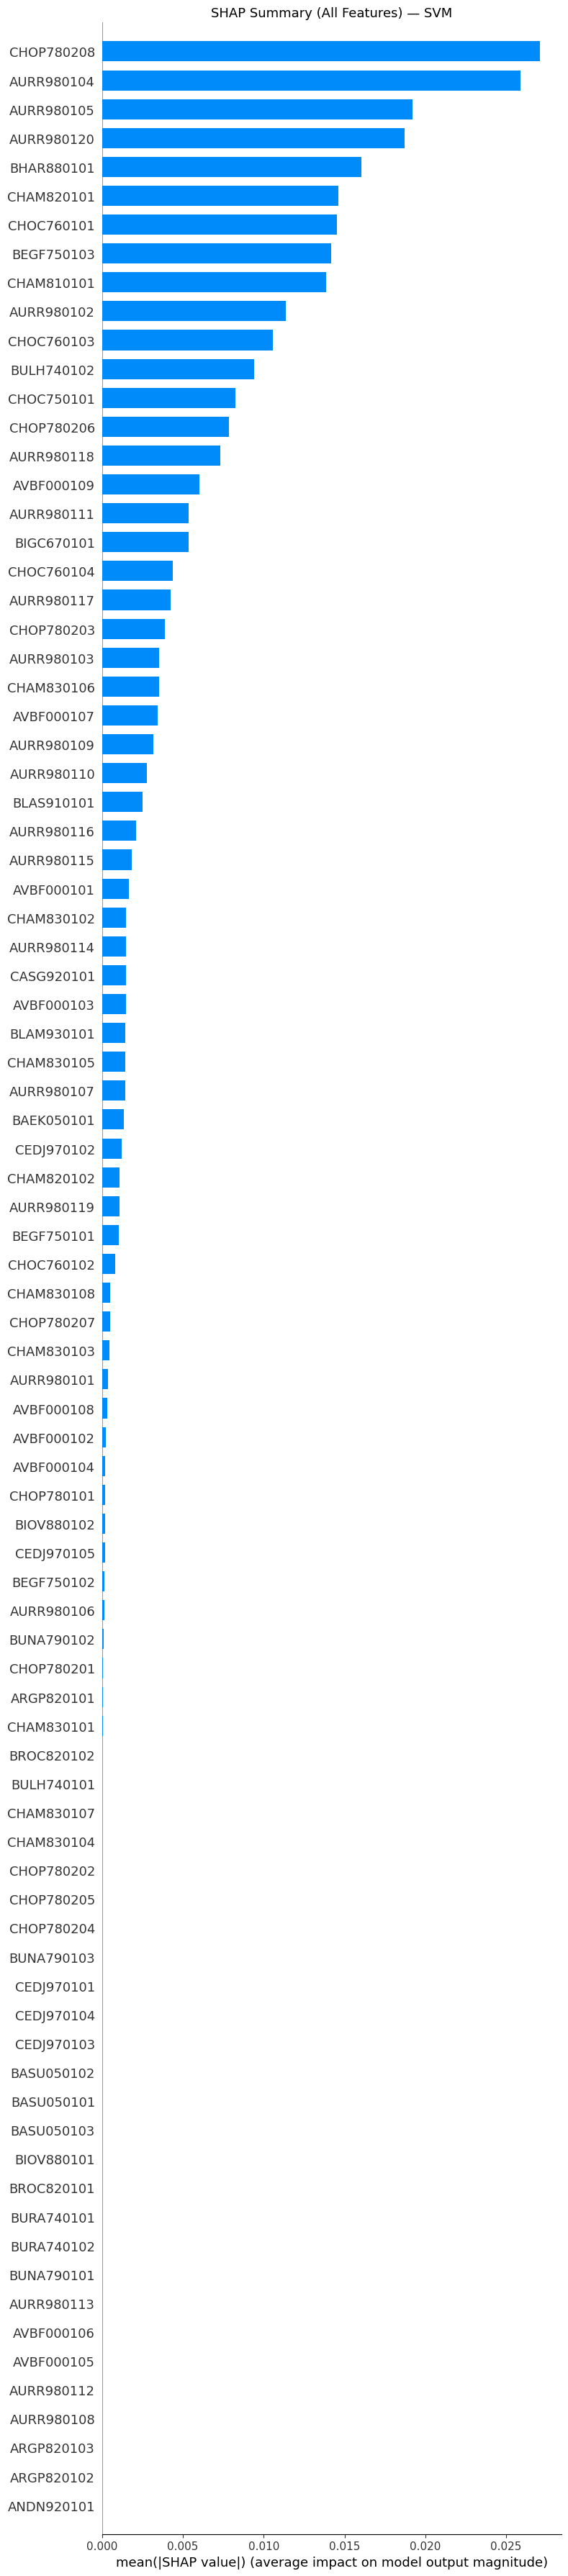

  Saved → shap_summary_plot_all_86.png


In [16]:
# ============================================================
# CELL 7 — Task 8 : SHAP Analysis (best model only)
# ============================================================

def shap_analysis(model_name:   str,
                  model,
                  X_train:      np.ndarray,
                  X_test:       np.ndarray,
                  feature_cols: list[str],
                  seed:         int = RANDOM_SEED) -> None:
    """
    Generate SHAP summary (beeswarm) and feature-importance (bar) plots
    for the best model.

    - Tree-based  (RF / XGBoost) → TreeExplainer
    - Others                     → KernelExplainer  (sampled background)

    Both plots are forced to display all AAindex features.
    """
    TREE_MODELS = {"RandomForest", "XGBoost"}

    print(f"\n[CELL 7] SHAP analysis for '{model_name}' …")

    # Force plots to show all available features (86 AAindex by default).
    max_display_features = len(feature_cols)

    # ── Choose explainer & compute SHAP values ───────────────────────────
    if model_name in TREE_MODELS:
        print("  Using TreeExplainer …")
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)

        # RandomForest returns list [class0_vals, class1_vals]
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values
        X_plot = X_test

    else:
        print("  Using KernelExplainer (background = 100 train samples) …")
        n_bg    = min(100, X_train.shape[0])
        bg      = shap.sample(X_train, n_bg, random_state=seed)

        predict_fn = (
            (lambda x: model.predict_proba(x)[:, 1])
            if hasattr(model, "predict_proba")
            else model.predict
        )
        explainer = shap.KernelExplainer(predict_fn, bg)

        n_explain = min(200, X_test.shape[0])
        X_plot    = X_test[:n_explain]
        sv        = explainer.shap_values(X_plot, silent=True)

    # ── Plot 1: SHAP values beeswarm (all 86 features) ───────────────────
    print(f"  Generating SHAP values beeswarm plot with all {max_display_features} features …")
    plt.figure(figsize=(14, 18))
    shap.summary_plot(
        sv, X_plot,
        feature_names=feature_cols,
        max_display=max_display_features,
        show=False
    )
    plt.title(f"SHAP Values (All Features) — {model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig("shap_values_plot_all_86.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved → shap_values_plot_all_86.png")

    # ── Plot 2: SHAP summary bar (all 86 features) ───────────────────────
    print(f"  Generating SHAP summary bar plot with all {max_display_features} features …")
    plt.figure(figsize=(14, 18))
    shap.summary_plot(
        sv, X_plot,
        feature_names=feature_cols,
        plot_type="bar",
        max_display=max_display_features,
        show=False
    )
    plt.title(f"SHAP Summary (All Features) — {model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig("shap_summary_plot_all_86.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved → shap_summary_plot_all_86.png")


# ── Run ──────────────────────────────────────────────────────
shap_analysis(best_name, best_model, X_train, X_test, feature_cols)

In [17]:
# ============================================================
# CELL 8 — Final Summary
# ============================================================

print("\n" + "=" * 65)
print("  PIPELINE COMPLETE")
print("=" * 65)
print(f"\n  Total samples used   : {len(features_df)}")
print(f"  Feature dimensions   : {features_df.shape[1]}  "
      f"(AAindex-only by default)")
print(f"\n  Best model           : {best_name}")
print(f"  Best params          : {best_params[best_name]}")
print(f"\n  Model Comparison (includes MCC, AUC-PR):\n")
print(results_df.to_string(index=False))
print("\n  Outputs saved:")
print("    • model_comparison.csv")
print("    • svm_10_runs_results.csv")
print("    • svm_10_runs_summary.csv")
print("    • shap_values_plot_all_86.png")
print("    • shap_summary_plot_all_86.png")
print("=" * 65)


  PIPELINE COMPLETE

  Total samples used   : 1300
  Feature dimensions   : 86  (AAindex-only by default)

  Best model           : SVM
  Best params          : {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

  Model Comparison (includes MCC, AUC-PR):

             Model  Accuracy  Precision  Recall     F1    MCC  ROC-AUC  AUC-PR
               SVM    0.8000     0.8162   0.955 0.8802 0.3347   0.8535  0.9529
LogisticRegression    0.8077     0.8261   0.950 0.8837 0.3736   0.8528  0.9532
           XGBoost    0.8115     0.8326   0.945 0.8852 0.3945   0.8166  0.9337
      RandomForest    0.8077     0.8409   0.925 0.8810 0.3990   0.7957  0.9214
               KNN    0.8115     0.8213   0.965 0.8874 0.3787   0.7629  0.8957

  Outputs saved:
    • model_comparison.csv
    • svm_10_runs_results.csv
    • svm_10_runs_summary.csv
    • shap_values_plot_all_86.png
    • shap_summary_plot_all_86.png
